In [2]:
from __future__ import annotations

import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from quant_pml.hedge.market_futures_hedge import MarketFuturesHedge
from quant_pml.runner import build_backtest

from deep_momentum.strategies.logistic_momentum import LogisticMomentum
from deep_momentum.config.project_experiment_config import ProjectExperimentConfig
from deep_momentum.config.project_trading_config import ProjectTradingConfig

QUANTILE = 0.1

In [3]:
strategy = LogisticMomentum(
    mode="long_short",
    quantile=QUANTILE,
    C=1.0,
)

hedger = MarketFuturesHedge()

In [4]:
strategy_name = strategy.__class__.__name__

preprocessor, runner = build_backtest(
    experiment_config=ProjectExperimentConfig(),
    trading_config=ProjectTradingConfig(),
    rebal_freq="ME",
)

Backtest on 2010-02-01 00:00:00 to 2024-12-31 00:00:00
Num Train Iterations: 179
Num Hedge Iterations: 3773
Num OOS Daily Points: 3755
Avg Num Stocks in Universe: 2533.43


In [5]:
res = runner(
    feature_processor=preprocessor,
    strategy=strategy,
    hedger=hedger,
)

Computing Weights:   0%|          | 0/179 [00:00<?, ?it/s]/Users/pavelkovyrzin/Desktop/HSE/deep-momentum/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
Computing Weights:   1%|          | 1/179 [00:00<01:20,  2.20it/s]/Users/pavelkovyrzin/Desktop/HSE/deep-momentum/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
Comp

In [6]:
res.to_pandas().loc[["sharpe", "alpha_benchmark", "ir_benchmark"]]

,value
metric,
sharpe,0.116610
alpha_benchmark,-0.014289
ir_benchmark,-0.173281


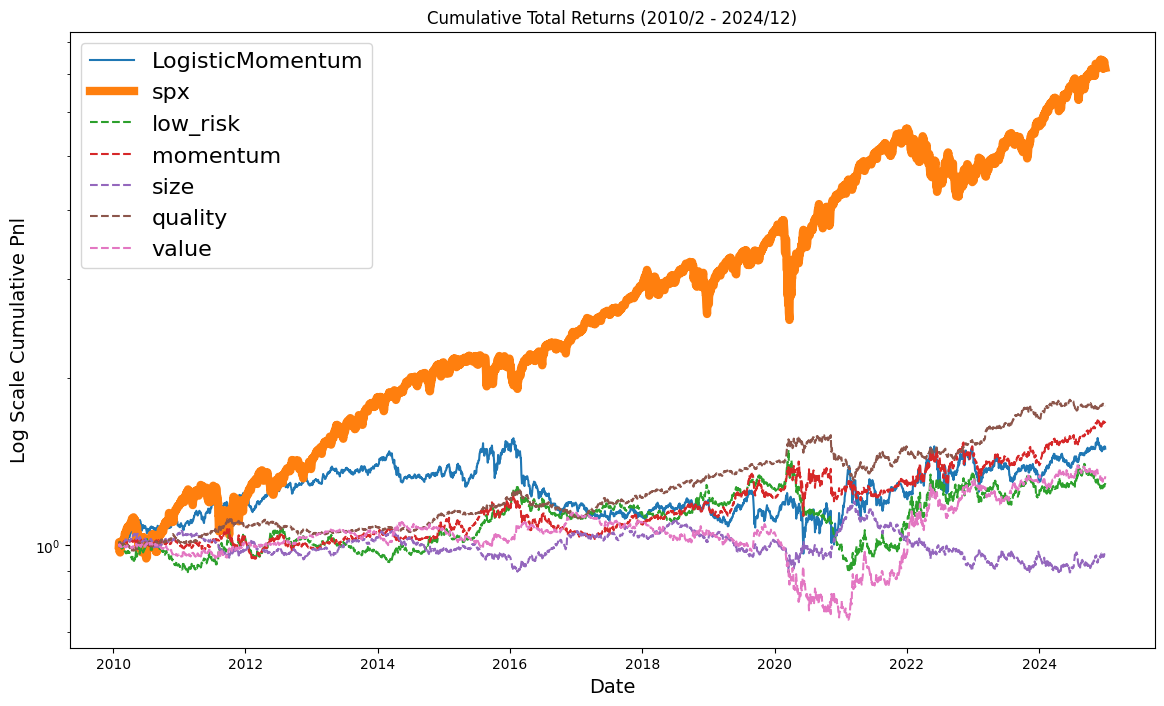

In [7]:
runner.plot_cumulative(
    strategy_name=strategy_name,
    include_factors=True,
)